# vMF pooled PVAR baseline comparison

This notebook loads the pooled factor-PVAR outputs together with the new baseline outputs, then compares metrics, confusion structure, and smooth-vs-sharp transition behavior.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import config
OUT = PROJECT_ROOT / config.OUTPUT_DIR
comparison_path = OUT / 'vmf_baseline_comparison.csv'
comparison = pd.read_csv(comparison_path)
comparison

,mode,N_units,common_T,K,p,train_frac,train_end,baseline_task,task_levels,mse,rmse,r2,accuracy,kl,cross_entropy,rf,rg,rh,max_iter,tol
0,vmf_pooled_factor_pvar,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.088761,0.297927,0.169816,0.439895,1.620278,1.757424,3.0,3.0,3.0,15.0,0.0001
1,baseline_persistence,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.143966,0.379428,-0.346519,0.425296,10.085363,10.222510,NaN,NaN,NaN,NaN,NaN
2,baseline_pooled_varx_ridge,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.088804,0.298000,0.169414,0.439773,1.402474,1.539621,NaN,NaN,NaN,NaN,NaN
3,baseline_markov_transition,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.094931,0.308109,0.112106,0.425562,1.496940,1.634087,NaN,NaN,NaN,NaN,NaN
4,baseline_multinomial_logit,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.088747,0.297904,0.169948,0.440565,1.395643,1.532790,NaN,NaN,NaN,NaN,NaN


In [2]:
cols = ['mode','mse','rmse','r2','accuracy','kl','cross_entropy']
comparison[cols].sort_values('mse')

,mode,mse,rmse,r2,accuracy,kl,cross_entropy
4,baseline_multinomial_logit,0.088747,0.297904,0.169948,0.440565,1.395643,1.532790
0,vmf_pooled_factor_pvar,0.088761,0.297927,0.169816,0.439895,1.620278,1.757424
2,baseline_pooled_varx_ridge,0.088804,0.298000,0.169414,0.439773,1.402474,1.539621
3,baseline_markov_transition,0.094931,0.308109,0.112106,0.425562,1.496940,1.634087
1,baseline_persistence,0.143966,0.379428,-0.346519,0.425296,10.085363,10.222510


In [3]:
factor_art = np.load(OUT / 'vmf_pvar_pooled_artifacts.npz', allow_pickle=True)
y_true = factor_art['y_true_oof']
y_pred = factor_art['y_pred_oof']
true_state = np.argmax(y_true, axis=1)
pred_state = np.argmax(y_pred, axis=1)
conf = pd.crosstab(pd.Series(true_state, name='true'), pd.Series(pred_state, name='pred'))
conf

pred,0,1,2,3,4,5,6
true,,,,,,,
0,89067,10297,21494,8908,1130,5298,1366
1,22832,25715,18260,5201,1137,2938,1345
2,28731,11460,55517,6686,301,4052,215
3,23325,5879,11614,30969,1185,4795,769
4,12605,4794,4309,4715,6853,2297,319
5,18129,4983,9754,5877,877,20557,402
6,14592,6273,3900,2597,451,1784,5268


In [4]:
for mode in comparison['mode']:
    if mode == 'vmf_pooled_factor_pvar':
        continue
    path = OUT / f'{mode}_predictions.npz'
    if path.exists():
        art = np.load(path, allow_pickle=True)
        pred_state = np.argmax(art['y_pred_oof'], axis=1)
        conf = pd.crosstab(pd.Series(true_state, name='true'), pd.Series(pred_state, name='pred'))
        print('\n===', mode, '===')
        display(conf)


=== baseline_persistence ===


pred,0,1,2,3,4,5,6
true,,,,,,,
0,68568,11484,19101,13329,6800,10166,8112
1,11351,28172,14648,6627,4798,5445,6387
2,19355,14330,51277,9311,2891,7092,2706
3,13103,6630,8935,33634,5196,7235,3803
4,6862,4602,3002,5049,11097,3608,1672
5,10335,5554,7307,6959,3447,24107,2870
6,7996,6662,2702,3612,1661,2905,9327



=== baseline_pooled_varx_ridge ===


pred,0,1,2,3,4,5,6
true,,,,,,,
0,82747,11869,19816,11332,1864,7846,2086
1,18485,28022,16344,6457,1730,4422,1968
2,24096,13378,53686,8431,775,6071,525
3,19256,6716,9754,33156,1835,6570,1249
4,10927,5092,3456,5176,7583,3196,462
5,14857,5567,8064,6679,1239,23397,776
6,13020,7201,3113,3278,537,2426,5290



=== baseline_markov_transition ===


pred,0,1,2,3,4,5,6
true,,,,,,,
0,70072,11551,19280,13133,6479,9711,7334
1,12089,28153,15188,6690,4454,5272,5582
2,20055,13872,51917,9227,2701,6775,2415
3,13878,6604,9197,33623,4776,7075,3383
4,7247,4736,3086,5757,10174,3492,1400
5,10971,5517,7554,7014,3247,23743,2533
6,8494,6983,2786,3576,1521,2864,8641



=== baseline_multinomial_logit ===


pred,0,1,2,3,4,5,6
true,,,,,,,
0,84381,12115,19555,10779,1895,6829,2006
1,19633,28178,16276,5999,1694,3776,1872
2,25612,13342,53492,7943,722,5445,406
3,20490,6804,9842,32615,1862,5871,1052
4,11432,5119,3343,4984,7780,2842,392
5,15915,5634,8041,6558,1295,22514,622
6,13423,7342,3085,3063,512,2098,5342


<Figure size 800x400 with 0 Axes>

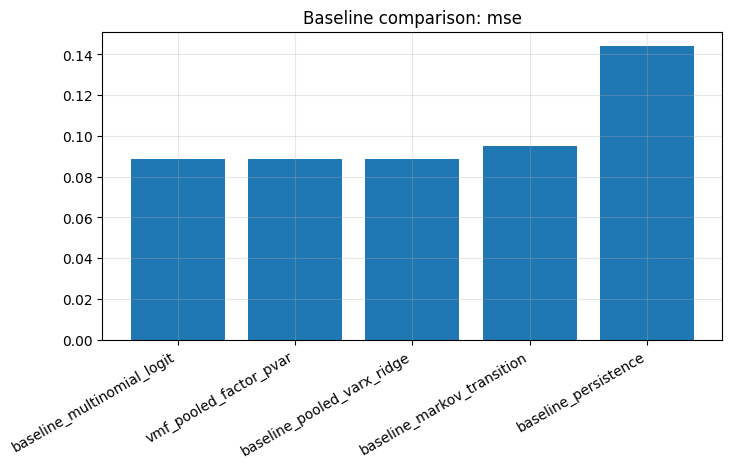

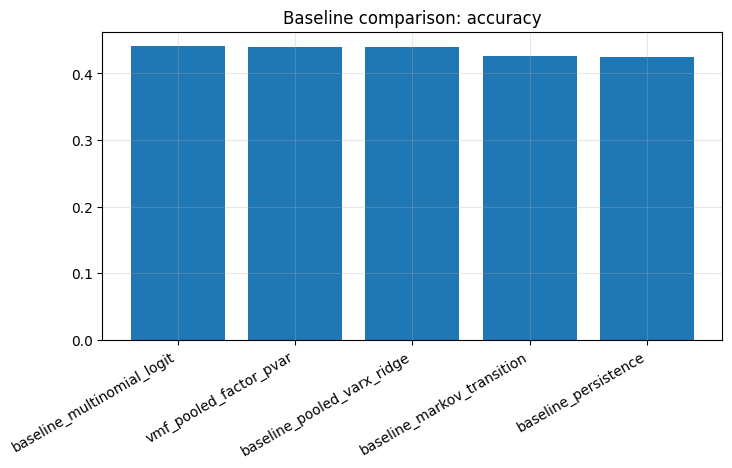

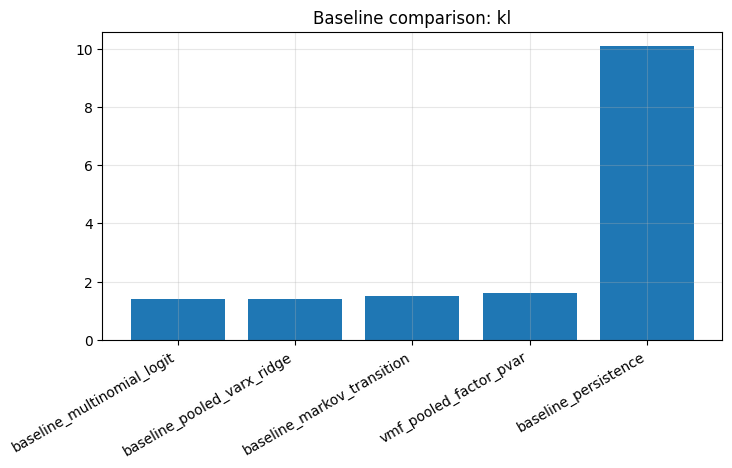

In [5]:
plt.figure(figsize=(8,4))
for metric in ['mse','accuracy','kl']:
    plt.figure(figsize=(8,4))
    tmp = comparison[['mode', metric]].sort_values(metric, ascending=(metric not in ['accuracy','r2']))
    plt.bar(tmp['mode'], tmp[metric])
    plt.xticks(rotation=30, ha='right')
    plt.title(f'Baseline comparison: {metric}')
    plt.grid(alpha=0.3)
    plt.show()

In [13]:


factor_art = np.load(OUT / 'vmf_pvar_pooled_artifacts.npz', allow_pickle=True)

f_t = factor_art['f_t']
g_t = factor_art['g_t']
h_t = factor_art['h_t']

print("f_t shape:", f_t.shape)
print("g_t shape:", g_t.shape)
print("h_t shape:", h_t.shape)

f_t shape: (4108, 3)
g_t shape: (4108, 3)
h_t shape: (4108, 3)


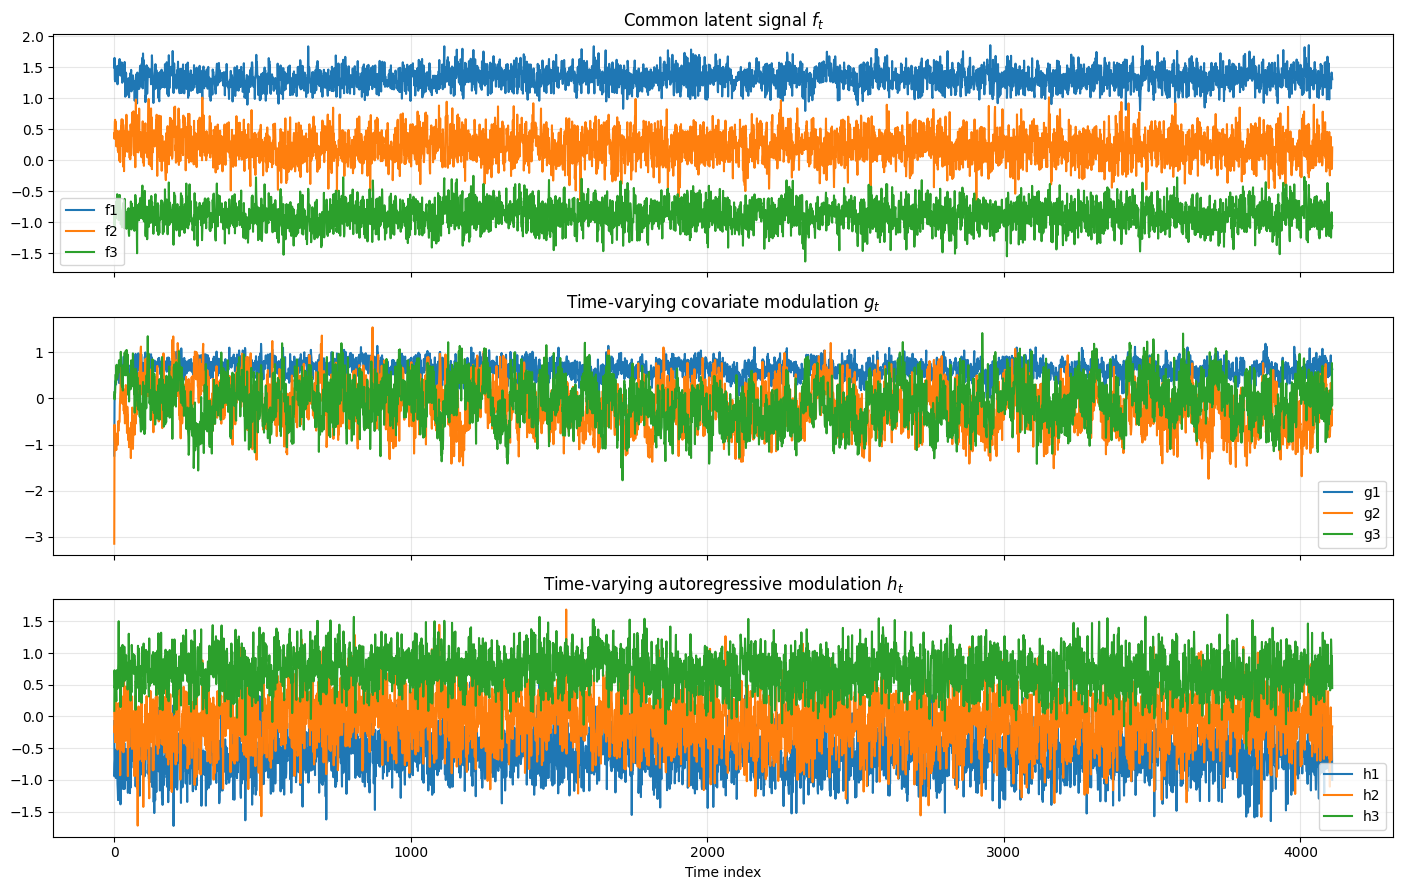

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for k in range(f_t.shape[1]):
    axes[0].plot(f_t[:, k], label=f'f{k+1}')
axes[0].set_title('Common latent signal $f_t$')
axes[0].legend()
axes[0].grid(alpha=0.3)

for k in range(g_t.shape[1]):
    axes[1].plot(g_t[:, k], label=f'g{k+1}')
axes[1].set_title('Time-varying covariate modulation $g_t$')
axes[1].legend()
axes[1].grid(alpha=0.3)

for k in range(h_t.shape[1]):
    axes[2].plot(h_t[:, k], label=f'h{k+1}')
axes[2].set_title('Time-varying autoregressive modulation $h_t$')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.xlabel('Time index')
plt.tight_layout()
plt.show()

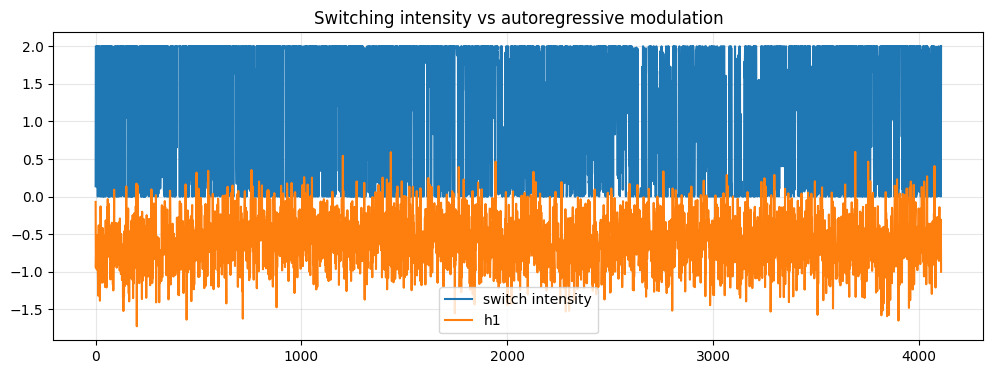

In [16]:
y_true = factor_art['y_true_oof']

# reshape if needed
T = y_true.shape[0]

switch_intensity = np.sum(np.abs(np.diff(y_true, axis=0)), axis=1)

plt.figure(figsize=(12,4))

plt.plot(switch_intensity[:h_t.shape[0]], label="switch intensity")
plt.plot(h_t[:,0], label="h1")

plt.title("Switching intensity vs autoregressive modulation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [17]:
np.corrcoef(switch_intensity[:h_t.shape[0]], h_t[:,0])

array([[1.        , 0.02143608],
       [0.02143608, 1.        ]])